In [ ]:
# 0 - data exploration

# The purpose of this notebook is to explore normalization visually by median
# insight: doing median normalization does visually make all the images appear the same
# brightness

In [2]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import sys
import os
import importlib
import numpy as np

sys.path.append(os.path.abspath(".."))
from src.data import load_images_from_metadata, filter_images

In [3]:
# load all of the data into metadata csv file including the new data (data_new_2))
from src.build_metadata import load_metadata
import importlib
import src.build_metadata as build_metadata

importlib.reload(build_metadata)
build_metadata.load_metadata(
    data_base_dir="../data",
    new_data_base_dir="../data_new",
    new_data_2_base_dir="../data_new_2",
    output_file="metadata.csv",
)

Applied human ratings to 851 DD rows.
Saved metadata to ..\metadata.csv
Combined records: 1345


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (1...
1,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (2...
2,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (3...
3,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (4...
4,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (5...
...,...,...,...,...,...,...,...,...
1340,5.8,Brooke,7.21.26,TEST,2BDR-9F02,25-143,flat,../data_test\{leveling-5.8}_P{Brooke}_D{7.21.2...
1341,6.3,Brooke,7.21.26,TEST,2BDR-9F02,25-141,flat,../data_test\{leveling-6.3}_P{Brooke}_D{7.21.2...
1342,6.8,Brooke,7.21.26,TEST,2BDR-9F02,25-104,flat,../data_test\{leveling-6.8}_P{Brooke}_D{7.21.2...
1343,8.0,Brooke,7.21.26,TEST,2BDR-9F02,25-125,flat,../data_test\{leveling-8.0}_P{Brooke}_D{7.21.2...


In [5]:
# get the data
data = load_images_from_metadata("../metadata.csv", crop_fraction = .4, use_cv2=True)

data_standards = filter_images(data, ImageType = "STD", State = "flat", DateCollected = ["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"])
data_real_paint = filter_images(data, ImageType = "DD", State = "flat")

Loaded 1345 images (cropping=ON, backend=cv2)
Filtered down to 177 images
Filtered down to 430 images


In [6]:
# normalization function

def normalize_by_median(img, target_median=120):
    img = img.astype(float)

    current_median = np.median(img)

    if current_median == 0:
        return img

    scale = target_median / current_median

    normalized = img * scale

    return np.clip(normalized, 0, 255).astype(np.uint8)

Cameras in display: ['2BDR-9F02', 'Unknown']
Number of images shown: 12


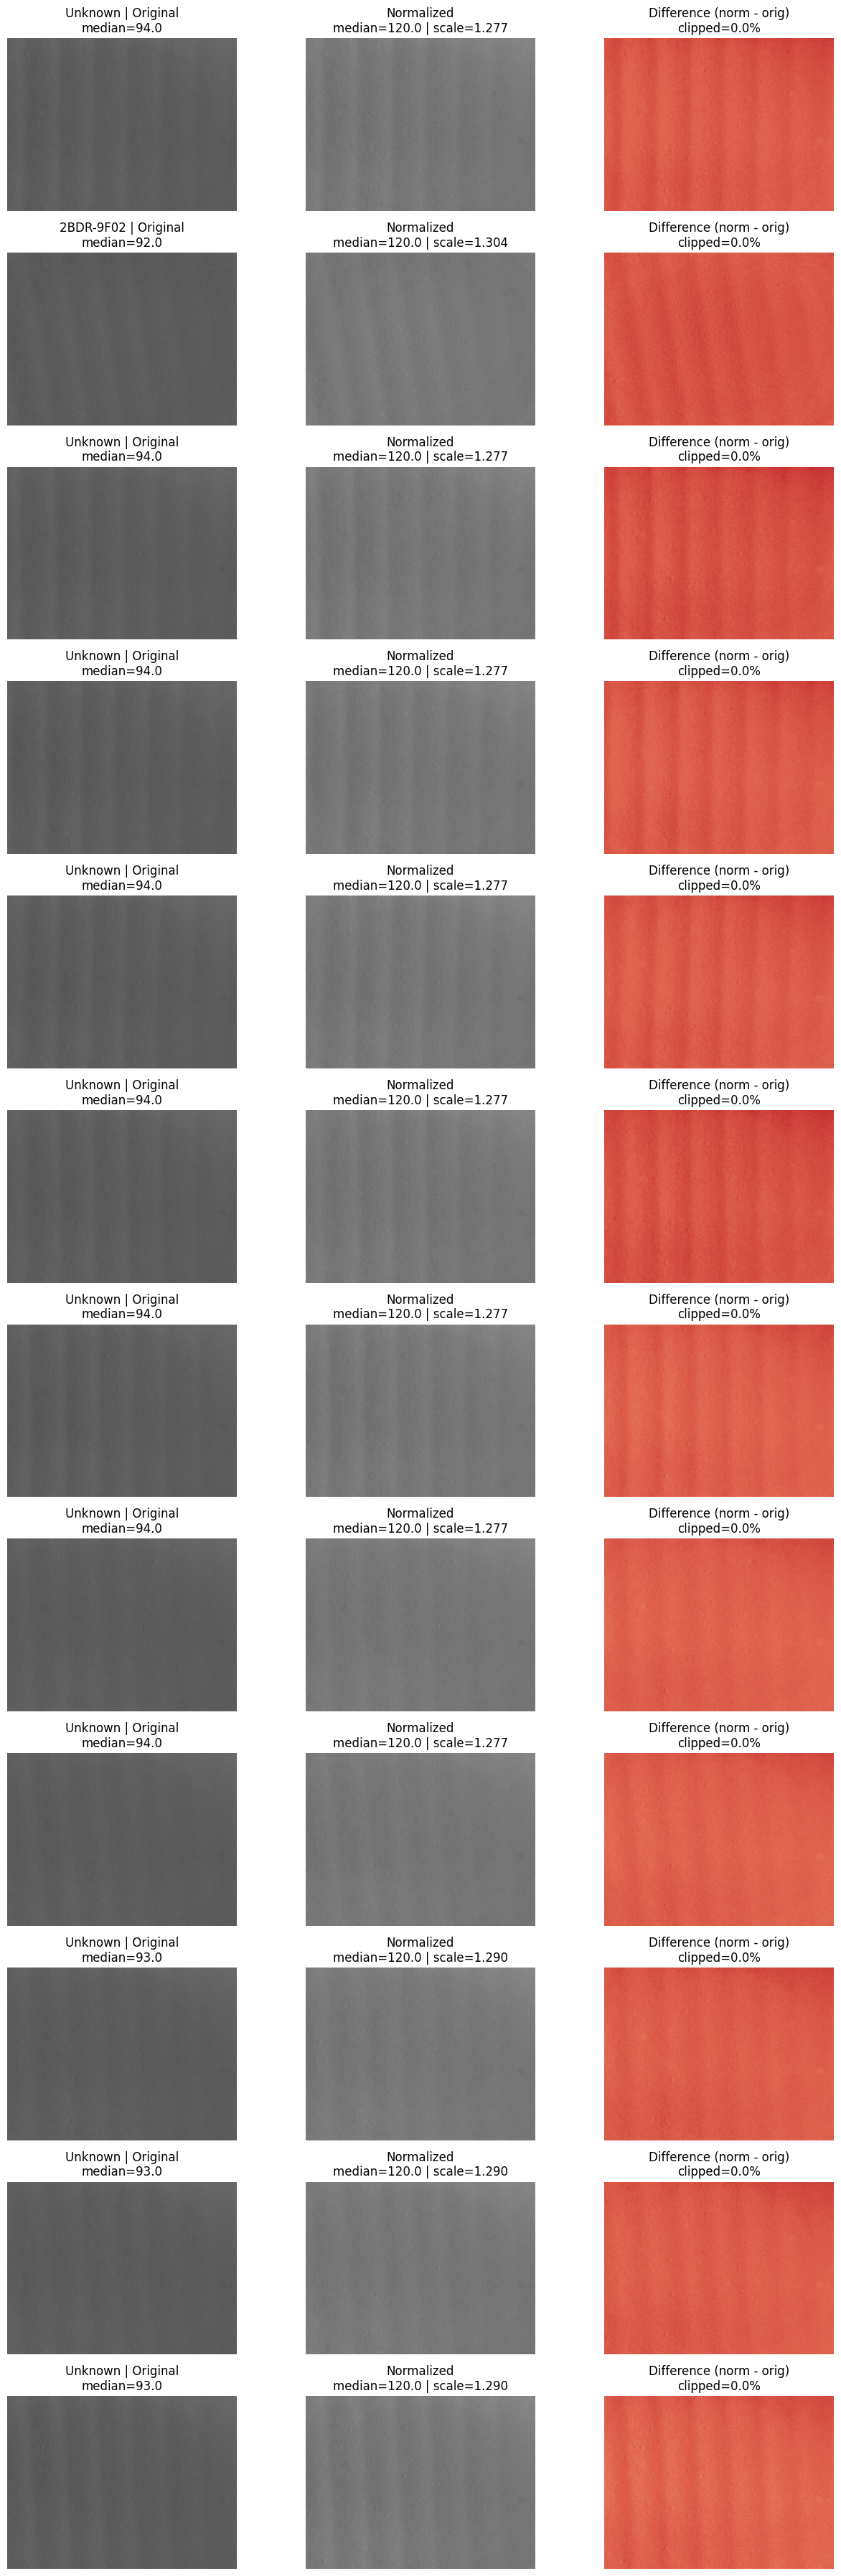

In [11]:
# Print more images: original vs normalized + difference map
import matplotlib.pyplot as plt

# Prefer DD flat images; fall back to all data if needed.
sample_pool = data_real_paint if len(data_real_paint) > 0 else data

# Normalize camera label text.
def get_camera_key(item):
    camera = item.get("GSCamera")
    key = str(camera).strip() if camera is not None else "Unknown"
    if key == "" or key.lower() in {"none", "nan"}:
        key = "Unknown"
    return key

# Show more examples overall.
max_examples = 12

# Start with one image per camera to keep diversity.
camera_examples = {}
for item in sample_pool:
    cam = get_camera_key(item)
    if cam not in camera_examples:
        camera_examples[cam] = item

selected_items = list(camera_examples.values())

# Fill remaining slots with additional images from the pool.
if len(selected_items) < max_examples:
    used_ids = {id(x) for x in selected_items}
    for item in sample_pool:
        if id(item) in used_ids:
            continue
        selected_items.append(item)
        if len(selected_items) >= max_examples:
            break

selected_items = selected_items[:max_examples]
num_examples = len(selected_items)

if num_examples == 0:
    print("No images found to display.")
else:
    shown_cameras = sorted({get_camera_key(item) for item in selected_items})
    print("Cameras in display:", shown_cameras)
    print("Number of images shown:", num_examples)

    fig, axes = plt.subplots(num_examples, 3, figsize=(13, 3 * num_examples))

    # Handle single-row case so indexing stays consistent.
    if num_examples == 1:
        axes = np.array([axes])

    for i, item in enumerate(selected_items):
        camera_name = get_camera_key(item)
        img = item["image"].astype(np.float32)
        img_norm = normalize_by_median(img, target_median=120).astype(np.float32)
        diff = img_norm - img

        orig_median = float(np.median(img))
        norm_median = float(np.median(img_norm))
        scale = 120.0 / orig_median if orig_median != 0 else np.nan
        clipped_pct = float(((img_norm <= 0) | (img_norm >= 255)).mean() * 100)

        ax_left = axes[i, 0]
        ax_mid = axes[i, 1]
        ax_right = axes[i, 2]

        ax_left.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax_left.set_title(f"{camera_name} | Original\nmedian={orig_median:.1f}")
        ax_left.axis("off")

        ax_mid.imshow(img_norm, cmap="gray", vmin=0, vmax=255)
        ax_mid.set_title(
            f"Normalized\nmedian={norm_median:.1f} | scale={scale:.3f}"
        )
        ax_mid.axis("off")

        m = np.max(np.abs(diff))
        m = 1.0 if m == 0 else m
        ax_right.imshow(diff, cmap="coolwarm", vmin=-m, vmax=m)
        ax_right.set_title(f"Difference (norm - orig)\nclipped={clipped_pct:.1f}%")
        ax_right.axis("off")

    plt.tight_layout()
    plt.show()

Showing 6 of 6 images from ../data/flat/1


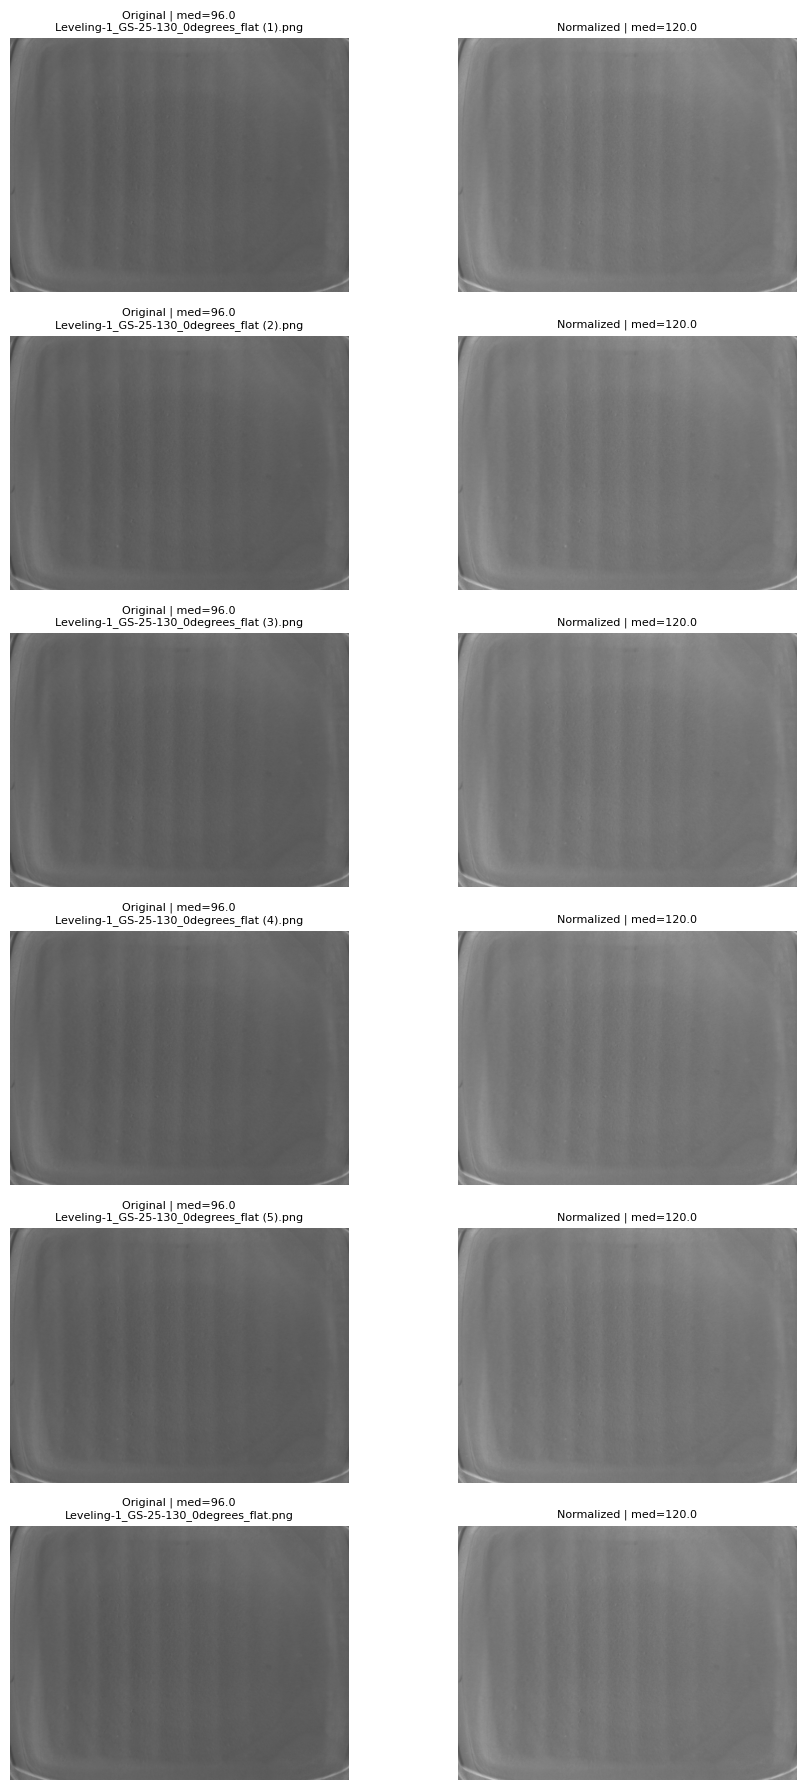

In [14]:
# Display sample images from data/flat/1: before vs after median normalization
import os
import cv2
import matplotlib.pyplot as plt

folder_path = "../data/flat/1"
max_show = 6
target_median = 120

if not os.path.isdir(folder_path):
    print(f"Folder not found: {folder_path}")
else:
    image_paths = sorted(
        os.path.join(folder_path, name)
        for name in os.listdir(folder_path)
        if name.lower().endswith(".png")
    )

    if len(image_paths) == 0:
        print(f"No PNG images found in {folder_path}")
    else:
        selected_paths = image_paths[:max_show]
        print(f"Showing {len(selected_paths)} of {len(image_paths)} images from {folder_path}")

        fig, axes = plt.subplots(len(selected_paths), 2, figsize=(10, 3 * len(selected_paths)))

        # Keep indexing consistent when only one image is shown.
        if len(selected_paths) == 1:
            axes = np.array([axes])

        for i, path in enumerate(selected_paths):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img_norm = normalize_by_median(img, target_median=target_median)

            orig_med = float(np.median(img))
            norm_med = float(np.median(img_norm))

            ax_left = axes[i, 0]
            ax_right = axes[i, 1]

            ax_left.imshow(img, cmap="gray", vmin=0, vmax=255)
            ax_left.set_title(
                f"Original | med={orig_med:.1f}\n{os.path.basename(path)}",
                fontsize=8,
            )
            ax_left.axis("off")

            ax_right.imshow(img_norm, cmap="gray", vmin=0, vmax=255)
            ax_right.set_title(f"Normalized | med={norm_med:.1f}", fontsize=8)
            ax_right.axis("off")

        plt.tight_layout()
        plt.show()